
Параметры расчета:
  t = 2
  m = 100 (количество узлов по x)
  n = 1000 (количество узлов по времени)
  space_step = 0.0101
  time_step = 0.0020
Выберите метод:
1 - явная схема крест
2 - неявная схема
1
Выберите уровень апроксимации:
1 - двухточечная аппроксимация с первым порядком
2 - трехточечная аппроксимация со вторым порядком
3 - двухточечная аппроксимация со вторым порядком
2
Выберите порядок апроксимации второго начального условия:
1 - первый
2 - второй
1


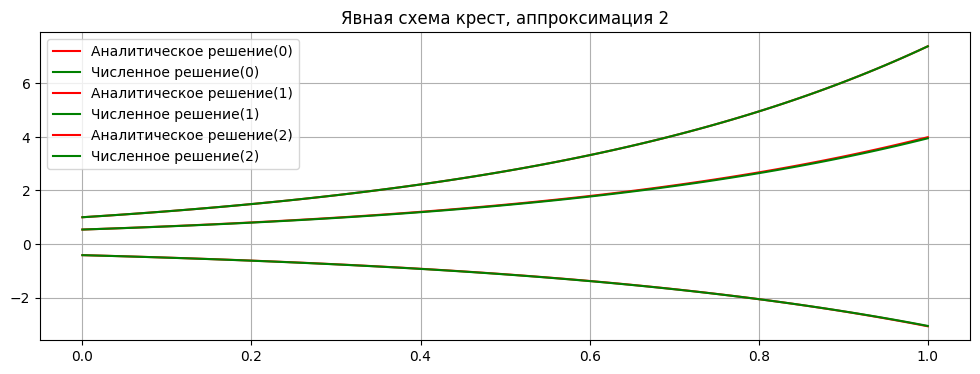

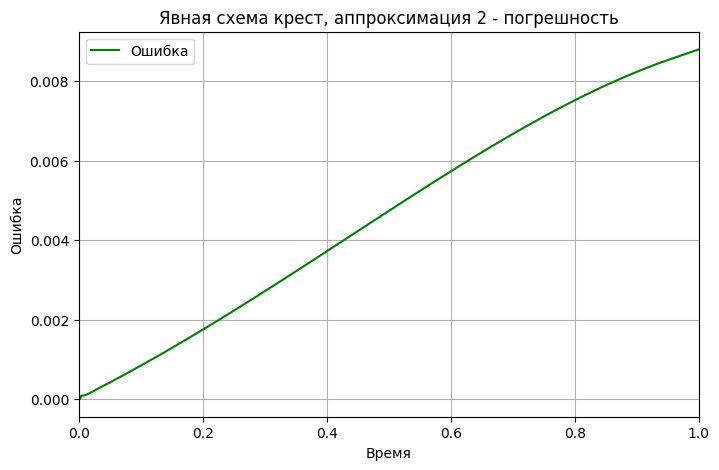


Максимальная погрешность: 0.008801

Хотите выполнить еще один расчет?
1 - Да
2 - Нет (выход)
1



Параметры расчета:
  t = 2
  m = 100 (количество узлов по x)
  n = 1000 (количество узлов по времени)
  space_step = 0.0101
  time_step = 0.0020
Выберите метод:
1 - явная схема крест
2 - неявная схема
2
Выберите уровень апроксимации:
1 - двухточечная аппроксимация с первым порядком
2 - трехточечная аппроксимация со вторым порядком
3 - двухточечная аппроксимация со вторым порядком
3
Выберите порядок апроксимации второго начального условия:
1 - первый
2 - второй
2


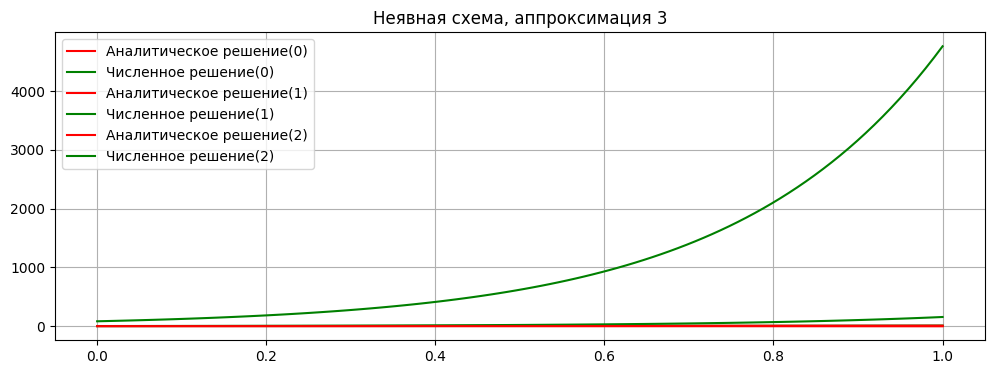

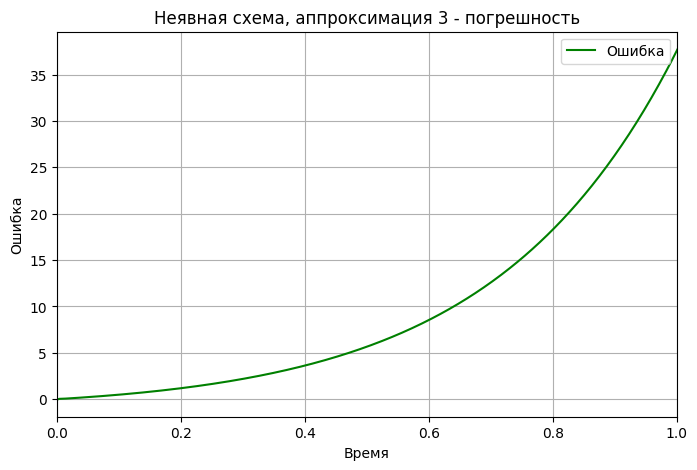


Максимальная погрешность: 37.733720

Хотите выполнить еще один расчет?
1 - Да
2 - Нет (выход)
2
Программа завершена.


In [5]:
# coding=windows-1251
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def Ux0(t):
    return 0

def Uxl(t):
    return 0

def U(x):
    return np.exp(2 * x)

def analyt_func(x, t):
    return np.exp(2 * x) * np.cos(t)

def gauss_elimination(A, b):
    m, n = A.shape
    Ab = np.hstack([A, b.reshape(-1, 1)])

    # Прямой ход
    for i in range(min(m, n)):
        max_row_index = np.argmax(np.abs(Ab[i:m, i])) + i
        Ab[[i, max_row_index]] = Ab[[max_row_index, i]]

        # Нормализация строки
        for j in range(i + 1, m):
            if Ab[i, i] == 0:
                continue
            factor = Ab[j, i] / Ab[i, i]
            Ab[j] -= factor * Ab[i]

    # Обратный ход
    x = np.zeros(n)
    for i in range(min(m, n) - 1, -1, -1):
        if i < m:
            if Ab[i, i] == 0:
                continue
            x[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]
    return x

x0 = 0
xl = 1
ap = 1
cp = -5

def autofill(x0, space_step, m, n, ap, time_step, aprox_f):
    Uarray = np.zeros([n, m])
    tmp_x = x0
    for j in range(m):
        Uarray[0][j] = U(tmp_x)
        if aprox_f == 1:
            Uarray[1][j] = U(tmp_x)
        if aprox_f == 2:
            Uarray[1][j] = U(tmp_x) + (ap**2 * 4 * U(tmp_x) + cp * U(tmp_x)) * time_step ** 2 / 2
        tmp_x += space_step
    return Uarray

def max_i(i, c):
    if i == 2:
        return max(c)/8
    return max(c)/4

def explicit(t, m, n, aprox, aprox_f, ans_time):
    x0 = 0
    xl = 1
    space_step = (xl - x0) / (m - 1)
    time_step = t / (n - 1)
    X = np.arange(x0, xl + space_step, space_step)
    Uarray = autofill(x0, space_step, m, n, ap, time_step, aprox_f)
    sigma = ap**2 * time_step**2 / space_step**2

    for k in range(1, n - 1):
        for j in range(1, m - 1):
            Uarray[k + 1][j] = Uarray[k][j + 1] * sigma + Uarray[k][j] * (-2 * sigma + 2 + cp * (time_step**2)) + Uarray[k][j - 1] * sigma - Uarray[k - 1][j]

        if aprox == 1:
            Uarray[k + 1][0] = -(1/space_step)/(-2-1/space_step) * Uarray[k + 1][1]
            Uarray[k + 1][m - 1] = (1/space_step)/(-2+1/space_step) * Uarray[k + 1][m-2]
        if aprox == 2:
            Uarray[k + 1][0] = ((2/space_step)*Uarray[k + 1][1]+(space_step/time_step)*Uarray[k][0])/(2/space_step + space_step/time_step +5*space_step + 4)
            Uarray[k + 1][m - 1] = ((2/space_step)*Uarray[k + 1][m-2]+(space_step/time_step)*Uarray[k][m-1])/(2/space_step + space_step/time_step +5*space_step - 4)
        if aprox == 3:
            Uarray[k + 1][0] = -(1/(2*space_step))/(-2-1/(2*space_step)) * Uarray[k + 1][2]
            Uarray[k + 1][m - 1] = (1/(2*space_step))/(-2+1/(2*space_step)) * Uarray[k + 1][m-3]

    return Uarray

def implicit(t, m, n, aprox, aprox_f, ans_time):
    x0 = 0
    xl = 1
    space_step = (xl - x0) / (m - 1)
    time_step = t / (n - 1)
    X = np.arange(x0, xl + space_step, space_step)
    Uarray = autofill(x0, space_step, m, n, ap, time_step, aprox_f)
    sigma = ap**2 * time_step**2 / space_step**2

    for k in range(1, n - 1):
        a = np.zeros(m)
        b = np.zeros(m)
        c = np.zeros(m)
        d = np.zeros(m)

        for j in range(1, m-1):
            a[j] = sigma
            b[j] = -(1 + 2 * sigma)
            c[j] = sigma
            d[j] = Uarray[k - 1][j] - (cp * time_step**2 + 2) * Uarray[k][j]

        if aprox == 1:
            b[0] = 2*space_step + 1
            c[0] = -1
            d[0] = 0
            a[m - 1] = 1
            b[m - 1] = 2*space_step - 1
            d[m - 1] = 0
        elif aprox == 2:
            b[0] = -1/space_step - space_step/(2*time_step**2) - 5*space_step/2
            c[0] = 1/space_step
            d[0] = (-space_step/(time_step**2) + 2) * Uarray[k][0] + space_step/(2*time_step**2) * Uarray[k-1][0]
            a[m - 1] = -1/space_step
            b[m - 1] = 1/space_step + space_step/(2*time_step**2) + 5*space_step/2
            d[m - 1] = (space_step/(time_step**2) + 2) * Uarray[k][m-1] - space_step/(2*time_step**2) * Uarray[k-1][m-1]
        elif aprox == 3:
            b[0] = 4*space_step + 1
            c[0] = -1
            d[0] = 0
            a[m - 1] = 1
            b[m - 1] = 4*space_step - 1
            d[m - 1] = 0

        A = np.zeros([m, m])
        A[0][0]=b[0]
        A[0][1]=c[0]
        A[m-1][m-2]=a[m-1]
        A[m-1][m-1]=b[m-1]

        for i in range(1,m-1):
            A[i][i-1] = a[i]
            A[i][i] = b[i]
            A[i][i+1] = c[i]

        Y = gauss_elimination(A, d)
        Uarray[k + 1] = Y

    return Uarray

def run_calculation():
    t=2
    m=100
    n=1000
    ans_time=1
    space_step = 1.0 / (m - 1)
    time_step = t / (n - 1)
    X = np.arange(x0, xl + space_step, space_step)

    print("\n" + "="*50)
    print("Параметры расчета:")
    print(f"  t = {t}")
    print(f"  m = {m} (количество узлов по x)")
    print(f"  n = {n} (количество узлов по времени)")
    print(f"  space_step = {space_step:.4f}")
    print(f"  time_step = {time_step:.4f}")
    print("="*50)

    print("Выберите метод:\n"
          "1 - явная схема крест\n"
          "2 - неявная схема")
    method_choice = int(input())

    print("Выберите уровень апроксимации:\n"
          "1 - двухточечная аппроксимация с первым порядком\n"
          "2 - трехточечная аппроксимация со вторым порядком\n"
          "3 - двухточечная аппроксимация со вторым порядком")
    aprox = int(input())

    print("Выберите порядок апроксимации второго начального условия:\n"
          "1 - первый\n"
          "2 - второй")
    aprox_f = int(input())

    if time_step**2 / space_step**2 >= 1 and method_choice == 1:
        print('Ошибка: условие устойчивости не выполнено!')
        return

    if method_choice == 1:
        Uarray = explicit(t, m, n, aprox, aprox_f, ans_time)
        method_name = "Явная схема крест"
    elif method_choice == 2:
        Uarray = implicit(t, m, n, aprox, aprox_f, ans_time)
        method_name = "Неявная схема"
    else:
        print("Неверный выбор метода")
        return

    in_array = int(ans_time / time_step)
    ans_t = in_array * time_step

    plt.figure(figsize=(12, 4))
    plt.plot(X, analyt_func(X, 0), color='red', label='Аналитическое решение(0)')
    plt.plot(X, Uarray[0], color='green', label='Численное решение(0)')
    plt.plot(X, analyt_func(X, 1), color='red', label='Аналитическое решение(1)')
    plt.plot(X, Uarray[500], color='green', label='Численное решение(1)')
    plt.plot(X, analyt_func(X, 2), color='red', label='Аналитическое решение(2)')
    plt.plot(X, Uarray[-1], color='green', label='Численное решение(2)')
    plt.title(f'{method_name}, аппроксимация {aprox}')
    plt.legend()
    plt.grid(True)
    plt.show()

    T = np.arange(0, 1 + time_step, time_step)
    nt = int(1 / time_step + 2)
    max_analitic_in_it_time = np.zeros(nt)

    for k in range(nt):
        in_it_time = analyt_func(X, k*time_step)
        max_analitic_in_it_time[k] = max_i(1, abs(in_it_time - Uarray[k]))

    plt.figure(figsize=(8, 5))
    plt.plot(T, max_analitic_in_it_time, color='green', label='Ошибка')
    plt.xlabel('Время')
    plt.ylabel('Ошибка')
    plt.xlim(0, 1)
    plt.title(f'{method_name}, аппроксимация {aprox} - погрешность')
    plt.legend()
    plt.grid()
    plt.show()

    print(f"\nМаксимальная погрешность: {np.max(max_analitic_in_it_time):.6f}")

# Основной цикл программы
while True:
    run_calculation()
    print("\n" + "="*50)
    print("Хотите выполнить еще один расчет?")
    print("1 - Да")
    print("2 - Нет (выход)")
    choice = input()
    if choice == "2":
        break
    print("\n" + "="*50 + "\n")

print("Программа завершена.")